# 地震波形数据

- 本节贡献者: {{田冬冬}}（作者）、{{姚家园}}（审稿）
- 最近更新日期: 2023-05-10
- 预计花费时间: 60 分钟

---

地震波形数据是地震学中最重要的数据。这一节介绍如何使用 ObsPy 下载地震波形数据。

首先，需要导入 ObsPy 中地震数据中心数据下载客户端 {class}`~obspy.clients.fdsn.client.Client`
以及用于处理时间的类 {class}`~obspy.core.utcdatetime.UTCDateTime`：

In [1]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

接下来，我们需要初始化一个 {class}`~obspy.clients.fdsn.client.Client` 对象。
ObsPy 的 `Client` 支持多个地震数据中心，这里我们选择使用
[IRIS 地震数据中心](https://ds.iris.edu/ds/nodes/dmc/)：

In [2]:
client = Client("IRIS")

我们以 2022 年 9 月 22 日发生在墨西哥的一个 Mw 6.8 级地震为例，申请该地震相关的
波形数据。该地震的基本信息为：

- 发震时刻：2022-09-22 06:16:09 UTC
- 经度：102.9518° W
- 纬度：18.247° N
- 深度：20.0 km
- 震级：mww 6.8

该地震的详细信息见 <https://ds.iris.edu/ds/nodes/dmc/tools/event/11600859>。

## 下载单个波形数据

下载波形数据时需要提供两个最基本的信息：

- 下载哪个地震台站哪个通道的数据，即需要指定台网（`network`）、台站（`station`）、
  位置码（`location`）和通道码（`channel`）
- 下载哪个时间段的数据，即指定数据开始时间（`starttime`）和结束时间（`endtime`）

下面的代码使用 {meth}`Client.get_waveforms() <obspy.clients.fdsn.client.Client.get_waveforms()>`
函数申请了 `IU.ANMO` 台站的宽频带垂直分量（即 `BHZ` 通道）的波形数据。数据开始时间为
2022-09-22T06:18:00（即发震后约两分钟），结束时间为 2022-09-22T06:30:00，
数据总长度为 12 分钟（即 720 秒）。
```{margin}
这里先假定我们已知台站 `IU.ANMO` 存在位置码为 `00`、通道码为 `BHZ` 的通道。
```

In [3]:
starttime=UTCDateTime("2022-09-22T06:18:00")  # 定义开始时间
st = client.get_waveforms(
    network="IU",               # 指定台网名
    station="ANMO",             # 指定台站名
    location="00",              # 指定位置码
    channel="BHZ",              # 指定通道码
    starttime=starttime,        # 指定开始时间
    endtime=starttime + 720     # 指定结束时间
)

函数的返回值为 {class}`~obspy.core.stream.Stream` 类型，赋值给变量 `st`。
使用 `print` 函数可以显示变量 `st` 的值：

In [4]:
print(st)

1 Trace(s) in Stream:
IU.ANMO.00.BHZ | 2022-09-22T06:18:00.019538Z - 2022-09-22T06:29:59.994538Z | 40.0 Hz, 28800 samples


可以看到{class}`~obspy.core.stream.Stream` 类型的变量 `st` 中包含了一个波形
（即 一个 {class}`~obspy.core.trace.Trace`），该波形对应的 ID 为 `IU.ANMO.00.BHZ`，
数据采样率为 40 Hz，共计 28800 个数据点。

{class}`~obspy.core.stream.Stream` 类提供了 {meth}`Stream.plot() <obspy.core.stream.Stream.plot>`
函数可以用于绘制波形。波形图的横轴为时间，纵轴为振幅：

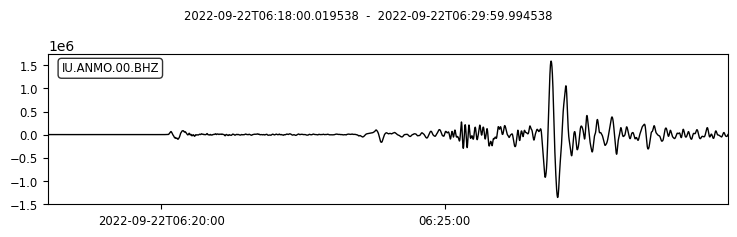

In [5]:
st.plot();

## 下载多个波形数据

`network`、`station`、`location` 和 `channel` 参数支持使用 UNIX 通配符，
以实现一次性下载多个波形数据的目的。通配符 `?` 表示匹配单个字符，通配符 `*`
表示匹配零个或多个字符。

下面的代码中 `channel` 参数指定为 `BH?` 以下载宽频带三分量数据：

In [6]:
st = client.get_waveforms(
    network="IU",
    station="ANMO",
    location="00",
    channel="BH?",              # "BH?" 表示下载三分量数据
    starttime=starttime,
    endtime=starttime + 720
)
print(st)

3 Trace(s) in Stream:
IU.ANMO.00.BH1 | 2022-09-22T06:18:00.019538Z - 2022-09-22T06:29:59.994538Z | 40.0 Hz, 28800 samples
IU.ANMO.00.BH2 | 2022-09-22T06:18:00.019538Z - 2022-09-22T06:29:59.994538Z | 40.0 Hz, 28800 samples
IU.ANMO.00.BHZ | 2022-09-22T06:18:00.019538Z - 2022-09-22T06:29:59.994538Z | 40.0 Hz, 28800 samples


函数返回的 {class}`~obspy.core.stream.Stream` 中包含三个 {class}`~obspy.core.trace.Trace`。
其中 `BHZ` 为垂直分量，`BH1` 和 `BH2` 为两个水平分量。绘图结果如下：

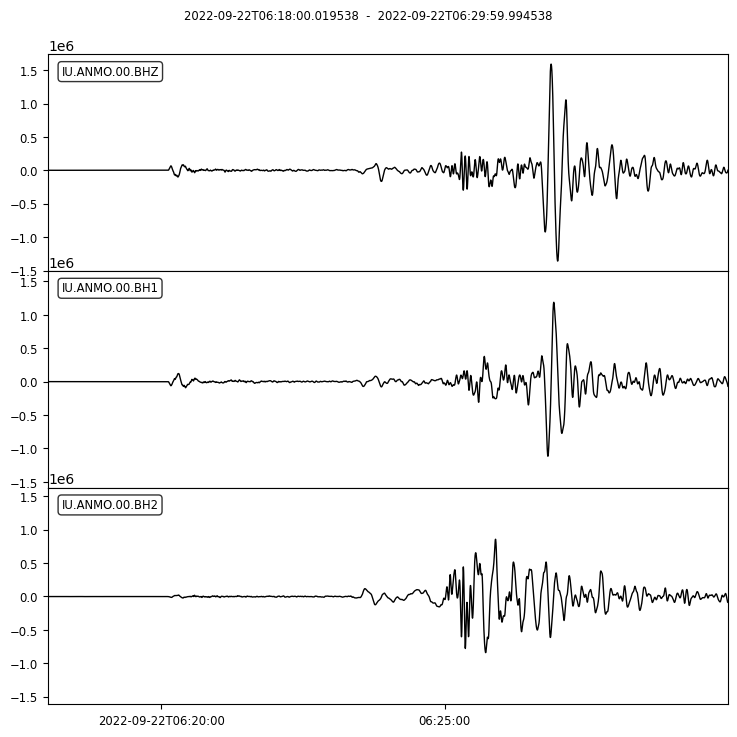

In [7]:
st.plot();

除了支持通配符外，这四个参数还支持用逗号分隔的代码列表。例如：

- `network="IU,IC"` 表示同时匹配 `IU` 和 `IC` 两个台网
- `station="ANMO,HKT,TUC"` 表示匹配三个台站名
- `location="--,00,01"` 表示匹配多个位置码，其中 `--` 表示位置码为空值
- `channel="BH?,SH?,LH?"` 表示匹配宽频带、短周期和长周期三分量

下面的代码中同时下载了三个台站的宽频带垂直分量的波形数据：

In [8]:
st = client.get_waveforms(
    network="IU",
    station="ANMO,HKT,TUC",     # IU 台网的三个台站
    location="00",
    channel="BHZ",
    starttime=starttime,
    endtime=starttime + 720
)
print(st)

3 Trace(s) in Stream:
IU.ANMO.00.BHZ | 2022-09-22T06:18:00.019538Z - 2022-09-22T06:29:59.994538Z | 40.0 Hz, 28800 samples
IU.HKT.00.BHZ  | 2022-09-22T06:18:00.019539Z - 2022-09-22T06:29:59.994539Z | 40.0 Hz, 28800 samples
IU.TUC.00.BHZ  | 2022-09-22T06:18:00.019538Z - 2022-09-22T06:29:59.994538Z | 40.0 Hz, 28800 samples


函数返回的 {class}`~obspy.core.stream.Stream` 中包含三个 {class}`~obspy.core.trace.Trace`。
绘图如下。

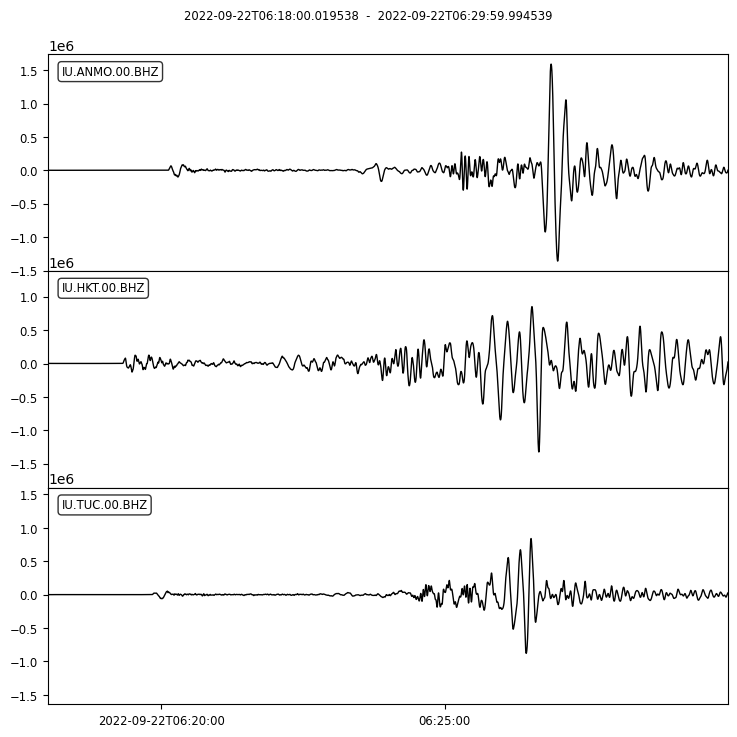

In [9]:
st.plot();

## 批量下载多个波形数据

上面的示例中，虽然使用 {meth}`Client.get_waveforms() <obspy.clients.fdsn.client.Client.get_waveforms()>`
可以一次性下载多个波形数据，但通配符本身不够灵活，且所有数据必须拥有相同的开始时间
和结束时间。

{meth}`Client.get_waveforms_bulk() <obspy.clients.fdsn.client.Client.get_waveforms_bulk()>` 函数
可以以更灵活的方式批量下载多个波形数据。该函数中最重要的参数是 `bulk` 参数。
该参数可以用多种不同的方式指定，包括：

- 列表。列表的每个元素为格式为 `(network, station, location, channel, starttime, endtime)` 的元组
- 符合 [FDSN Web Service 文档](https://www.fdsn.org/webservices/)所要求的请求字符串或文件

这里我们只介绍第一种方式。

In [10]:
bulk = [
    ("IU", "ANMO", "00", "BHZ", starttime, starttime + 720),
    ("IU", "HKT", "00", "BH?", starttime, starttime + 800),
    ("II", "PFO", "00", "BHZ", starttime + 100, starttime + 1200),
]
st = client.get_waveforms_bulk(bulk)
print(st)

5 Trace(s) in Stream:
II.PFO.00.BHZ  | 2022-09-22T06:19:40.019538Z - 2022-09-22T06:37:59.994538Z | 40.0 Hz, 44000 samples
IU.ANMO.00.BHZ | 2022-09-22T06:18:00.019538Z - 2022-09-22T06:29:59.994538Z | 40.0 Hz, 28800 samples
IU.HKT.00.BH1  | 2022-09-22T06:18:00.019538Z - 2022-09-22T06:31:19.994538Z | 40.0 Hz, 32000 samples
IU.HKT.00.BH2  | 2022-09-22T06:18:00.019538Z - 2022-09-22T06:31:19.994538Z | 40.0 Hz, 32000 samples
IU.HKT.00.BHZ  | 2022-09-22T06:18:00.019539Z - 2022-09-22T06:31:19.994539Z | 40.0 Hz, 32000 samples


在这个示例中，我们申请了 `IU.ANMO.00.BHZ`、`IU.HKT.00.BH?` 和 `II.PFO.00.BHZ` 的
波形数据，且每个波形数据的开始时间和结束时间均不同，最终申请得到 5 个波形数据。
绘图结果如下：

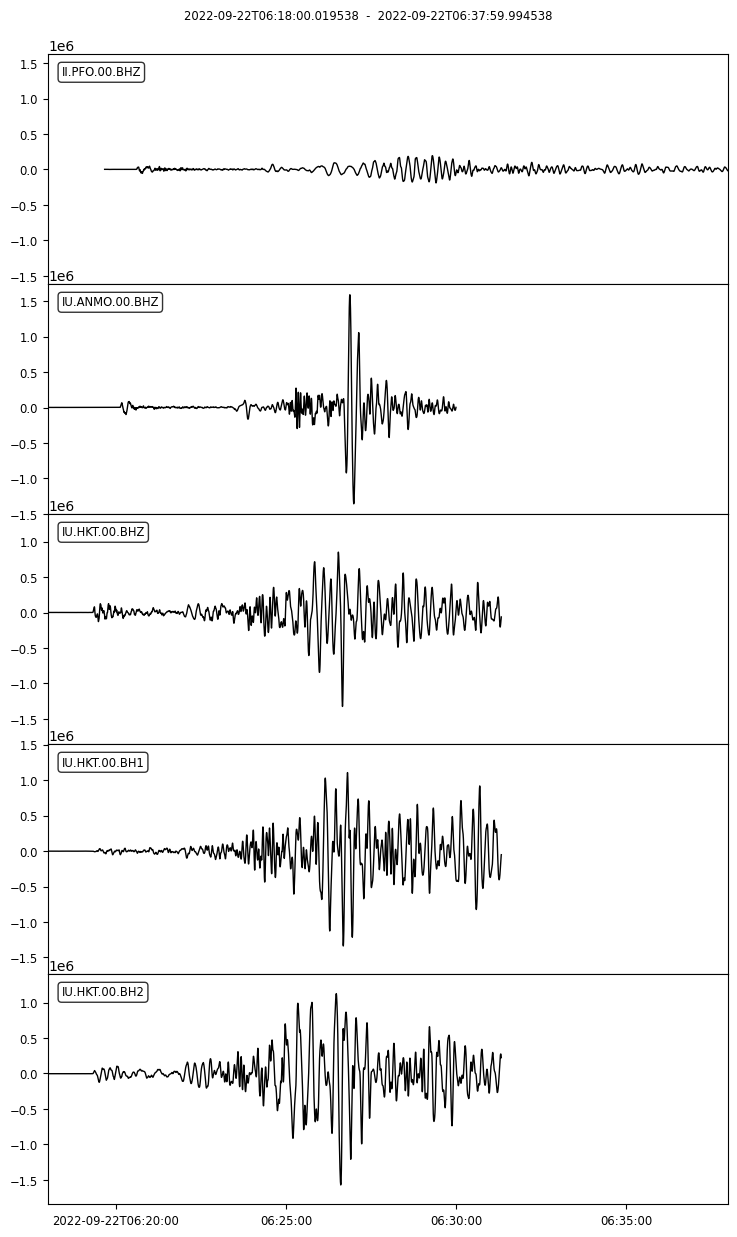

In [11]:
st.plot();

## 下载大量波形数据

上面的示例已经可以灵活地一次性下载多个地震波形数据，但要求用户必须自行准备 `bulk` 参数，
即用户需要首先获取地震和台站信息并对其进行筛选，然后自行构建 `bulk` 参数。在需要
下载大量波形数据时相对比较繁琐。

为了更方便地下载大量波形数据，ObsPy 提供了 {mod}`obspy.clients.fdsn.mass_downloader` 模块。
{mod}`~obspy.clients.fdsn.mass_downloader` 模块主要包含了三部分：

- {mod}`~obspy.clients.fdsn.mass_downloader.domain`：根据位置信息筛选台站
- {class}`~obspy.clients.fdsn.mass_downloader.restrictions.Restrictions`：用于设置波形数据的相关参数
- {class}`~obspy.clients.fdsn.mass_downloader.mass_downloader.MassDownloader`：用于下载数据

下面通过两个示例介绍 {mod}`~obspy.clients.fdsn.mass_downloader` 模块的基本用法。
更详细的用法参见官方文档。

### 下载地震波形数据

下面的示例展示了如何使用 {class}`~obspy.clients.fdsn.mass_downloader.mass_downloader.MassDownloader`
下载单个地震多台站的波形数据：
```
import obspy
from obspy.clients.fdsn.mass_downloader import CircularDomain, \
    Restrictions, MassDownloader

origin_time = obspy.UTCDateTime(2011, 3, 11, 5, 47, 32)

# 使用 CircularDomain 限定使用震中 30 到 40 度范围内的台站
domain = CircularDomain(
    latitude=18.247,
    longitude=-102.9518,
    minradius=30.0,
    maxradius=40.0
)

# Restriction 用于对波形进行进一步筛选
restrictions = Restrictions(
    # 设置波形的开始时间和结束时间
    starttime=origin_time,
    endtime=origin_time + 1200,
    # 丢弃所有数据中包含 gap（即存在中断）的数据
    reject_channels_with_gaps=True,
    # 实际获得的数据长度不小于数据申请的时间段长度的 95%
    minimum_length=0.95,
    # 通道优先级。当一个台站同时有 HH? 和 BH？数据时，优先下载 HH？数据
    channel_priorities=["HH?", "BH?"]
)

# 初始化
mdl = MassDownloader()
# 将数据下载到 waveforms 目录下，台站元数据下载到 stations 目录下
mdl.download(
    domain,
    restrictions,
    mseed_storage="waveforms",
    stationxml_storage="stations"
)
```

### 下载连续波形数据

下面的示例展示了如何使用 {class}`~obspy.clients.fdsn.mass_downloader.mass_downloader.MassDownloader`
下载连续波形数据：
```
import obspy
from obspy.clients.fdsn.mass_downloader import RectangularDomain, \
    Restrictions, MassDownloader

# 限制台站位于一个矩形区域内
domain = RectangularDomain(
    minlatitude=30,
    maxlatitude=50,
    minlongitude=5,
    maxlongitude=35
)

restrictions = Restrictions(
    # 设置数据的开始时间和结束时间
    starttime=obspy.UTCDateTime(2012, 1, 1),
    endtime=obspy.UTCDateTime(2013, 1, 1),
    # 将数据分块，每块的长度为 86400 秒。即一天的数据保存到一个文件中
    chunklength_in_sec=86400,
    # 设置要下载的数据的 network, station, location 和 channel 信息
    network="BW", station="A*", location="", channel="EH*",
    # 不删除存在数据中断的数据
    reject_channels_with_gaps=False,
    # 不限制数据的最小长度
    minimum_length=0.0,
)

mdl = MassDownloader(providers=["LMU", "GFZ"])  # 设置地震数据中心列表
mdl.download(
    domain,
    restrictions,
    mseed_storage="waveforms",
    stationxml_storage="stations"
)
```

## 其他地震数据申请软件

除了 ObsPy 外，还存在很多其他地震数据申请软件，包括但不限于：

- [SOD](http://www.seis.sc.edu/sod/)
- [Wilber 3](https://ds.iris.edu/wilber3)
- [irisFetch.m](https://ds.iris.edu/ds/nodes/dmc/manuals/irisfetchm/)

不同的软件各有其利弊，读者亦可了解并学习这些软件，并根据具体需求使用合适的软件。